In [1]:
import os
while not os.path.isdir('.git'):
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

# Theta bursts

In [2]:
idxs = np.arange(0, 20)

In [54]:
conditions = {
    "No TI": "subthreshold_conductance/theta_poisson/noTI_0.1",
    "0 Hz": "subthreshold_conductance/theta_poisson/1000_0_0.25_0.1",
    "5 Hz": "subthreshold_conductance/theta_poisson/1000_5_0.9_0.1",
    "130 Hz": "subthreshold_conductance/theta_poisson/1000_130_0.9_0.1"
}

colors = {
    "No TI": "tab:blue",
    "5 Hz": "tab:orange",
    "130 Hz": "tab:green",
    "0 Hz": "tab:red"
}

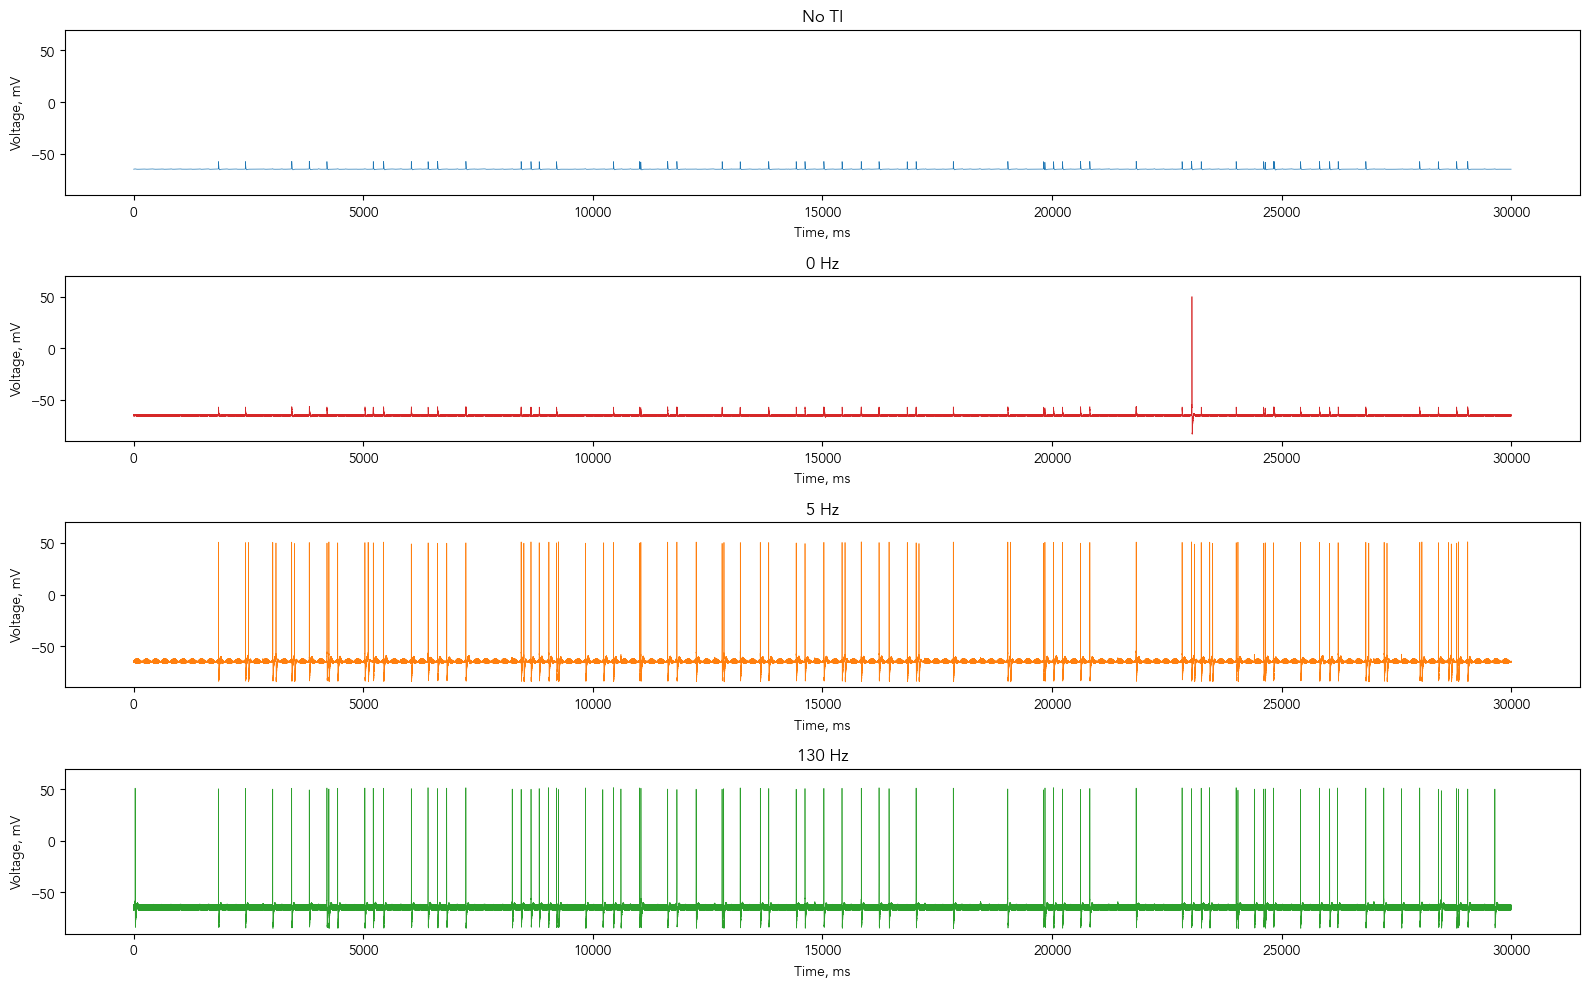

In [55]:
fig, axs = plt.subplots(nrows = len(conditions), ncols = 1, figsize = (16, 2.5 * len(conditions)))

idx = 11

for condition, ax in zip(conditions.keys(), axs):
    filename = conditions[condition]
    color = colors[condition]

    voltage = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/voltage.csv")

    ax.plot(
        voltage.Time,
        voltage.Voltage,
        linewidth = 0.5,
        color = color
    )

    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Voltage, mV")
    ax.set_ylim(-90, 70)

    ax.set_title(condition)

fig.tight_layout()
plt.show()

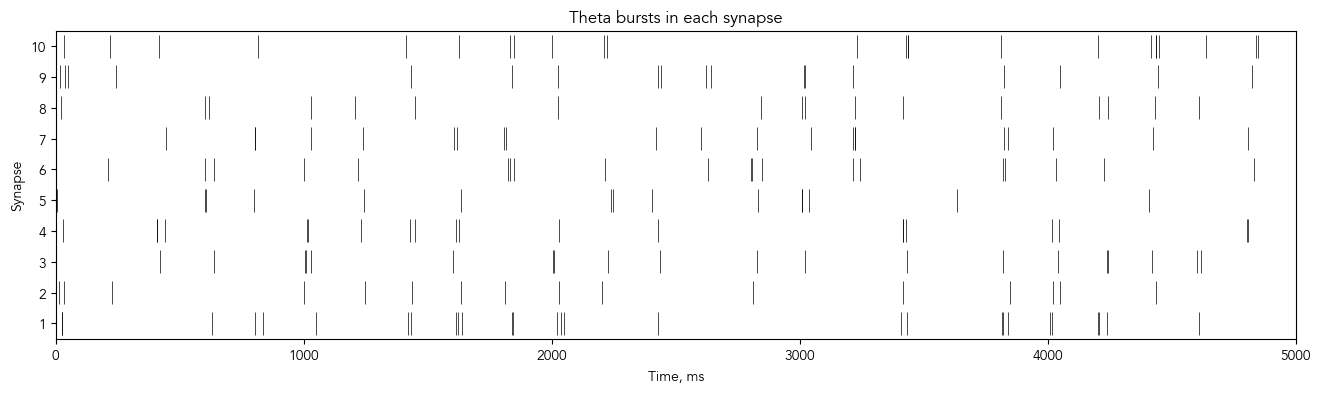

In [56]:
spike_times = pd.read_csv(f"output/temporal-interference/{idx}/{conditions['No TI']}/synapse_stimuli.csv", header=None)
spike_times = spike_times.fillna('').values.tolist()
spike_times = [[x for x in row if x != ""] for row in spike_times]

plt.figure(figsize = (16, 4))

for i, spikes in enumerate(spike_times):
    plt.eventplot(spikes, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

plt.ylim(0.5, 10.5)
plt.ylabel("Synapse")
plt.yticks(np.arange(1, 11, 1))

plt.xlabel("Time, ms")
plt.xlim(0, 5_000)
plt.xticks(np.arange(0, 5_000 + 1000, 1000))

plt.title("Theta bursts in each synapse")
plt.show()

In [57]:
def expand_time(original, max_time = 10_000):
    original["Time"] = (original["Time"] / 0.025).round() * 0.025
    original = original.sort_values("Time")

    new_time = np.arange(0, max_time + 0.025, 0.025)

    expanded = pd.DataFrame({ "Time": new_time })
    expanded = pd.merge_asof(expanded, original, on = "Time", direction = "backward")

    return expanded

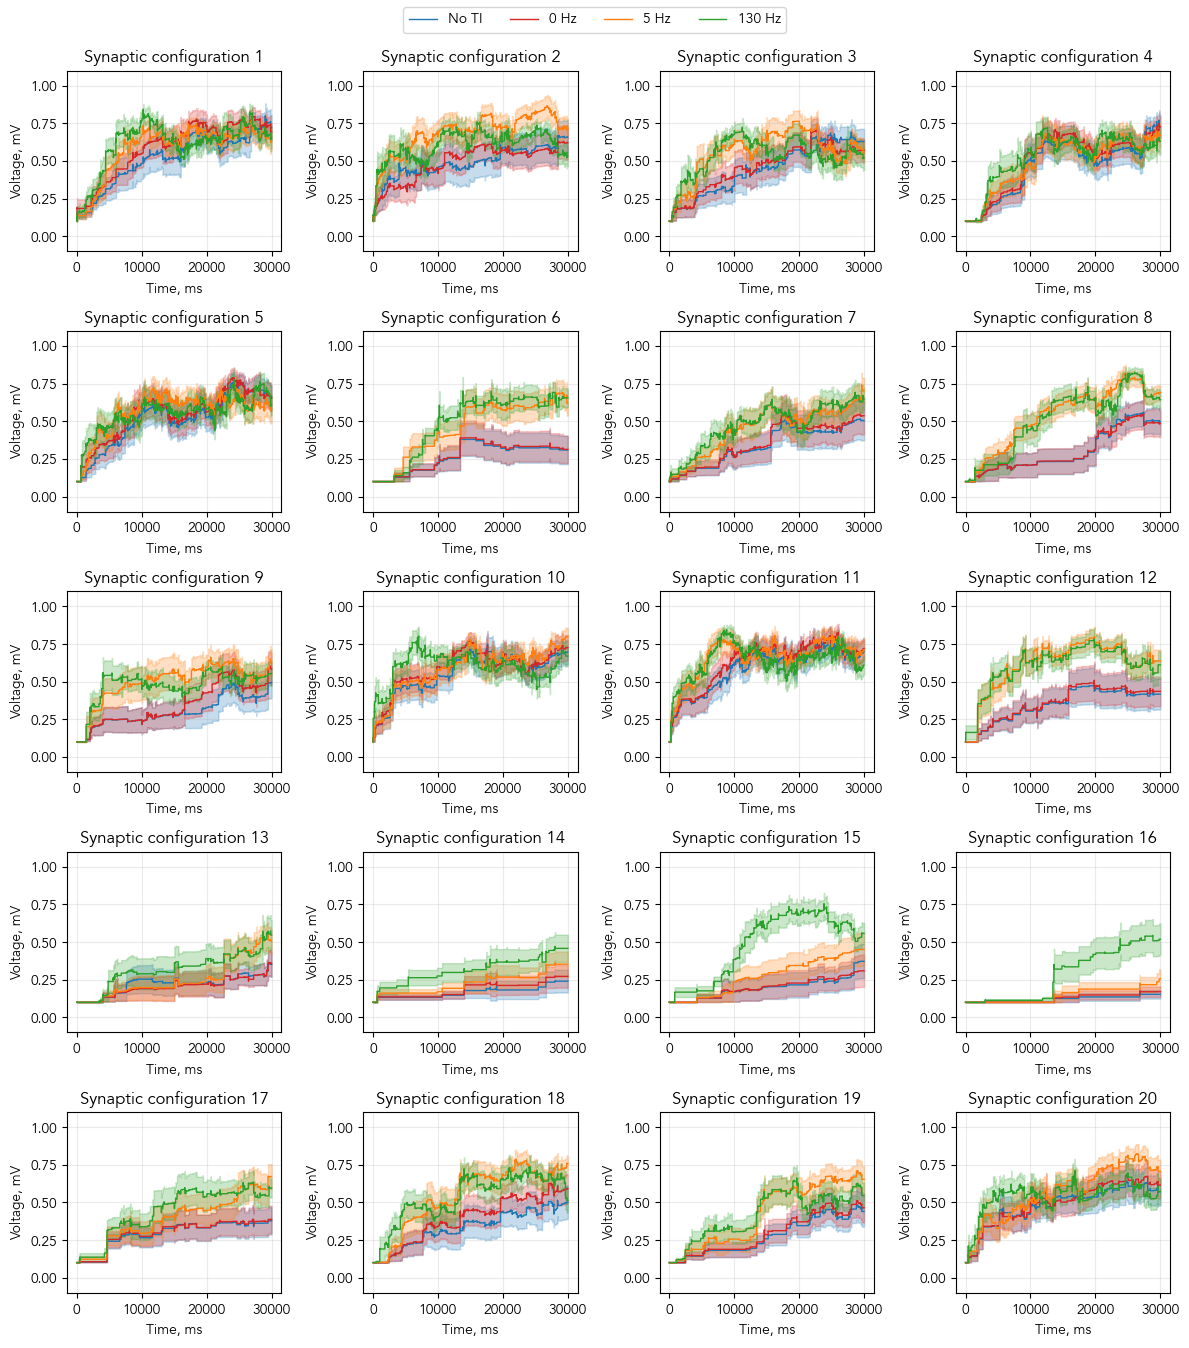

In [58]:
fig, axs = plt.subplots(nrows = int(len(idxs) / 4), ncols = 4, figsize = (12, 2.5 * int(len(idxs) / 4) + 1))
axs = axs.flatten()

for idx, ax in zip(idxs, axs):
    for condition in conditions.keys():
        filename = conditions[condition]
        color = colors[condition]

        try:
            weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv")
            weights = expand_time(weights, max_time = 30_000)
            time = weights.Time
            weights = np.array([weights[f"Synapse{i}"] for i in range(0, 10)])

            mean = weights.mean(axis = 0)
            error = weights.std(axis = 0) / np.sqrt(weights.shape[0])

            ax.plot(
                time,
                mean,
                linewidth = 1,
                label = condition,
                color = color
            )
            ax.fill_between(
                time, mean - error, mean + error,
                alpha = 0.25,
                color = color
            )
        except:
            print(idx)

    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Voltage, mV")
    ax.set_ylim(-0.1, 1.1)

    ax.set_title(f"Synaptic configuration {idx + 1}")
    ax.grid(True, alpha = 0.25)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc = "upper center", ncol = len(labels))

fig.tight_layout()
fig.subplots_adjust(top = 0.95)

plt.show()

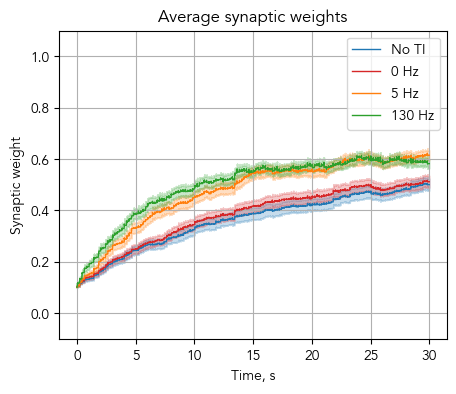

In [60]:
plt.figure(figsize = (5, 4))

for condition in conditions.keys():
    filename = conditions[condition]
    color = colors[condition]

    weights = []
    time = []

    for idx in idxs:
        try:
            synapse_weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv")
            synapse_weights = expand_time(synapse_weights, max_time = 30_000)
            time = synapse_weights.Time / 1000
    
            synapse_weights = np.array([ synapse_weights[f"Synapse{i}"] for i in range(0, 10) ])
            weights.append(synapse_weights)
        except:
            print(idx)

    weights = np.concatenate(weights)

    mean = weights.mean(axis = 0)
    error = weights.std(axis = 0)  / np.sqrt(weights.shape[0])

    plt.plot(
        time,
        mean,
        linewidth = 1,
        label = condition,
        color = color
    )
    plt.fill_between(
        time, mean - error, mean + error,
        alpha = 0.25,
        color = color
    )

    plt.xlabel("Time, s")
    plt.ylabel("Synaptic weight")
    plt.ylim(-0.1, 1.1)

    plt.title("Average synaptic weights")

plt.legend()
plt.grid(True)

fig.tight_layout()
plt.show()

In [38]:
conditions = {
    "No TI": "subthreshold_conductance/theta_poisson/noTI_0.1",
    "5 Hz (1000)": "subthreshold_conductance/theta_poisson/1000_5_0.9_0.1",
    "5 Hz (9000)":"subthreshold_conductance/theta_poisson/9000_5_0.9_0.1"
}

colors = {
    "No TI": "tab:blue",
    "5 Hz (1000)": "tab:orange",
    "5 Hz (9000)": "tab:red"
}

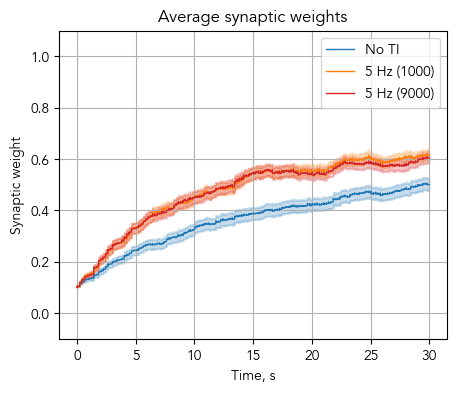

In [39]:
plt.figure(figsize = (5, 4))

for condition in conditions.keys():
    filename = conditions[condition]
    color = colors[condition]

    weights = []
    time = []

    for idx in idxs:
        try:
            synapse_weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv")
            synapse_weights = expand_time(synapse_weights, max_time = 30_000)
            time = synapse_weights.Time / 1000

            synapse_weights = np.array([ synapse_weights[f"Synapse{i}"] for i in range(0, 10) ])
            weights.append(synapse_weights)
        except:
            print(idx)

    weights = np.concatenate(weights)

    mean = weights.mean(axis = 0)
    error = weights.std(axis = 0)  / np.sqrt(weights.shape[0])

    plt.plot(
        time,
        mean,
        linewidth = 1,
        label = condition,
        color = color
    )
    plt.fill_between(
        time, mean - error, mean + error,
        alpha = 0.25,
        color = color
    )

    plt.xlabel("Time, s")
    plt.ylabel("Synaptic weight")
    plt.ylim(-0.1, 1.1)

    plt.title("Average synaptic weights")

plt.legend()
plt.grid(True)

fig.tight_layout()
plt.show()